# Comparação entre modelos para o dataset Credit Card Fraud

**Base:** [Credit Card Fraud Detection](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud) (`mlg-ulb/creditcardfraud`)

## 1. Load do dataset

In [15]:
import pandas as pd
import numpy as np

df = pd.read_csv(r"C:\Users\Rodrigo\Desktop\Trabalho_SI\dados\creditcard.csv")
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


In [16]:
df["Class"].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

### Remoção de instancias duplicadas

In [17]:
df.duplicated().sum() 

np.int64(1081)

In [18]:
df = df.drop_duplicates()
df = df.drop(columns=["Time"])

## 2. Separando x e y

In [19]:
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

In [20]:
X

array([[-1.35980713e+00, -7.27811733e-02,  2.53634674e+00, ...,
         1.33558377e-01, -2.10530535e-02,  1.49620000e+02],
       [ 1.19185711e+00,  2.66150712e-01,  1.66480113e-01, ...,
        -8.98309914e-03,  1.47241692e-02,  2.69000000e+00],
       [-1.35835406e+00, -1.34016307e+00,  1.77320934e+00, ...,
        -5.53527940e-02, -5.97518406e-02,  3.78660000e+02],
       ...,
       [ 1.91956501e+00, -3.01253846e-01, -3.24963981e+00, ...,
         4.45477214e-03, -2.65608286e-02,  6.78800000e+01],
       [-2.40440050e-01,  5.30482513e-01,  7.02510230e-01, ...,
         1.08820735e-01,  1.04532821e-01,  1.00000000e+01],
       [-5.33412522e-01, -1.89733337e-01,  7.03337367e-01, ...,
        -2.41530880e-03,  1.36489143e-02,  2.17000000e+02]],
      shape=(283726, 29))

## 3. Padronização dos valores

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 4. Salvar variáveis

In [23]:
import pickle

with open("dados.pkl", "wb") as f:
    pickle.dump(
        {
            "X_train_scaled": X_train_scaled,
            "X_test_scaled": X_test_scaled,
            "y_train": y_train,
            "y_test": y_test,
        },
        f,
    )

## 5. Treino e avaliação com holdout (80/20)

Acurácia não serve como métrica aqui: prever "legítima" para tudo já acerta 99,83%. 

`class_weight="balanced"` faz o modelo penalizar mais o erro na classe minoritária, compensando o
desbalanceamento sem reamostrar os dados.

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (average_precision_score, roc_auc_score,
                             recall_score, precision_score, f1_score,
                             confusion_matrix, classification_report)

modelos = {
    "Regressão Logística": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        min_samples_split=5,
        class_weight="balanced",
        n_jobs=-1,
        random_state=42
    ),
}

resultados = []
previsoes = {}

for nome, modelo in modelos.items():
    modelo.fit(X_train_scaled, y_train)
    pred = modelo.predict(X_test_scaled)
    proba = modelo.predict_proba(X_test_scaled)[:, 1]
    previsoes[nome] = (pred, proba)   # proba alimenta as curvas da seção 7

    resultados.append({
        "Modelo": nome,
        "PR-AUC": average_precision_score(y_test, proba),
        "ROC-AUC": roc_auc_score(y_test, proba),
        "Recall": recall_score(y_test, pred),
        "Precisão": precision_score(y_test, pred),
        "F1": f1_score(y_test, pred),
    })

tabela_holdout = pd.DataFrame(resultados).set_index("Modelo").round(4)
tabela_holdout

,PR-AUC,ROC-AUC,Recall,Precisão,F1
Modelo,,,,,
Regressão Logística,0.6752,0.9648,0.8737,0.0558,0.1049
Random Forest,0.8149,0.9421,0.7263,0.9324,0.8166


In [25]:
for nome, (pred, _) in previsoes.items():
    print(f"===== {nome} =====")
    print("Matriz de confusão (linhas = real, colunas = previsto):")
    print(confusion_matrix(y_test, pred))
    print(classification_report(y_test, pred,
                                target_names=["Legítima", "Fraude"], digits=3))

===== Regressão Logística =====
Matriz de confusão (linhas = real, colunas = previsto):
[[55247  1404]
 [   12    83]]
              precision    recall  f1-score   support

    Legítima      1.000     0.975     0.987     56651
      Fraude      0.056     0.874     0.105        95

    accuracy                          0.975     56746
   macro avg      0.528     0.924     0.546     56746
weighted avg      0.998     0.975     0.986     56746

===== Random Forest =====
Matriz de confusão (linhas = real, colunas = previsto):
[[56646     5]
 [   26    69]]
              precision    recall  f1-score   support

    Legítima      1.000     1.000     1.000     56651
      Fraude      0.932     0.726     0.817        95

    accuracy                          0.999     56746
   macro avg      0.966     0.863     0.908     56746
weighted avg      0.999     0.999     0.999     56746



## 6. Validação cruzada k-fold (k = 5) no treino

Os mesmos dois modelos, agora avaliados por validação cruzada no `X_train`. O `X_test` continua
intocado.

- **`StratifiedKFold`** mantém a proporção de fraudes em cada dobra. Com 0,17% de positivos, um
  k-fold comum poderia gerar uma dobra com pouquíssimas fraudes e distorcer a métrica.
- **A padronização entra no `Pipeline`** e passamos o `X_train` cru, não o `X_train_scaled`. Assim o
  `StandardScaler` é reajustado dentro de cada dobra, usando só os dados de treino daquela dobra —
  caso contrário a média e o desvio já teriam sido calculados incluindo a dobra de validação.

In [26]:
from sklearn.base import clone
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate

metricas = {
    "average_precision": "PR-AUC",
    "roc_auc": "ROC-AUC",
    "recall": "Recall",
    "precision": "Precisão",
    "f1": "F1",
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

linhas = []
scores_kfold = {}   # guardado para o gráfico de dispersão da seção 7

for nome, modelo in modelos.items():
    pipe = make_pipeline(StandardScaler(), clone(modelo))
    scores = cross_validate(pipe, X_train, y_train, cv=cv,
                            scoring=list(metricas), n_jobs=-1)
    scores_kfold[nome] = scores

    linha = {"Modelo": nome}
    for chave, rotulo in metricas.items():
        s = scores[f"test_{chave}"]
        linha[rotulo] = f"{s.mean():.4f} ± {s.std():.4f}"
    linhas.append(linha)

tabela_kfold = pd.DataFrame(linhas).set_index("Modelo")
tabela_kfold

,PR-AUC,ROC-AUC,Recall,Precisão,F1
Modelo,,,,,
Regressão Logística,0.7540 ± 0.0271,0.9817 ± 0.0084,0.9073 ± 0.0291,0.0582 ± 0.0059,0.1093 ± 0.0102
Random Forest,0.8393 ± 0.0273,0.9671 ± 0.0130,0.8095 ± 0.0449,0.8980 ± 0.0211,0.8507 ± 0.0268


## 7. Gráficos de apoio à decisão

Três figuras, cada uma respondendo a uma pergunta diferente sobre qual modelo escolher.

Cada modelo tem uma cor fixa em todos os gráficos — azul para a Regressão Logística, laranja para o
Random Forest — para que a identidade não precise ser reaprendida a cada figura.

In [27]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, roc_curve

# Uma cor fixa por modelo, reaproveitada em todas as figuras.
CORES = {"Regressão Logística": "#2a78d6", "Random Forest": "#eb6834"}

SUPERFICIE, TINTA, TINTA_2, MUDO, GRADE = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9"

plt.rcParams.update({
    "figure.facecolor": SUPERFICIE,
    "axes.facecolor": SUPERFICIE,
    "axes.edgecolor": "#c3c2b7",
    "axes.labelcolor": TINTA_2,
    "axes.titlecolor": TINTA,
    "axes.titlesize": 11,
    "axes.titleweight": "bold",
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": GRADE,
    "grid.linewidth": 0.8,
    "xtick.color": MUDO,
    "ytick.color": MUDO,
    "font.size": 10,
    "legend.frameon": False,
    "figure.dpi": 120,
})


def limpar_bordas(ax, lados=("top", "right")):
    for lado in lados:
        ax.spines[lado].set_visible(False)

### 7.1 Curva Precisão–Recall vs. Curva ROC

As tabelas mostram cada modelo em **um único limiar de decisão** (0,5). As curvas mostram o
desempenho em **todos os limiares** — é a comparação mais completa, porque o limiar é um parâmetro
que se ajusta depois.

As duas curvas lado a lado deixam ver por que a métrica escolhida muda a resposta.

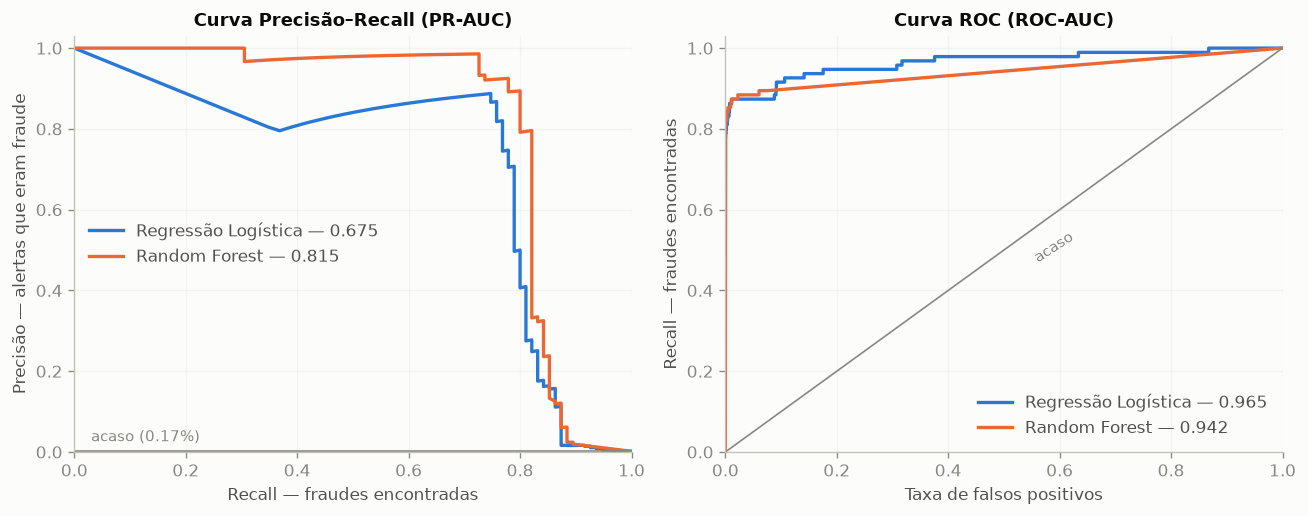

In [28]:
fig, (ax_pr, ax_roc) = plt.subplots(1, 2, figsize=(11, 4.4))

for nome, cor in CORES.items():
    _, proba = previsoes[nome]

    prec, rec, _ = precision_recall_curve(y_test, proba)
    ax_pr.plot(rec, prec, color=cor, lw=2,
               label=f"{nome} — {average_precision_score(y_test, proba):.3f}")

    fpr, tpr, _ = roc_curve(y_test, proba)
    ax_roc.plot(fpr, tpr, color=cor, lw=2,
                label=f"{nome} — {roc_auc_score(y_test, proba):.3f}")

# Linha de referência: o que um classificador aleatório alcançaria.
acaso = y_test.mean()
ax_pr.axhline(acaso, color=MUDO, lw=1)
ax_pr.text(0.03, acaso + 0.025, f"acaso ({acaso:.2%})", color=MUDO, fontsize=9)
ax_pr.set(xlabel="Recall — fraudes encontradas",
          ylabel="Precisão — alertas que eram fraude",
          title="Curva Precisão–Recall (PR-AUC)", xlim=(0, 1), ylim=(0, 1.03))
ax_pr.legend(loc="center left", labelcolor=TINTA_2)

ax_roc.plot([0, 1], [0, 1], color=MUDO, lw=1)
ax_roc.text(0.55, 0.47, "acaso", color=MUDO, fontsize=9, rotation=33)
ax_roc.set(xlabel="Taxa de falsos positivos",
           ylabel="Recall — fraudes encontradas",
           title="Curva ROC (ROC-AUC)", xlim=(0, 1), ylim=(0, 1.03))
ax_roc.legend(loc="lower right", labelcolor=TINTA_2)

for ax in (ax_pr, ax_roc):
    limpar_bordas(ax)

fig.tight_layout()
plt.show()

### 7.2 Discussão

Um número sozinho não diz se a diferença entre os modelos é consistente. Aqui estão as **5 medições
do k-fold** (uma por dobra), a média de cada modelo e, como losango vazado, o valor obtido no
holdout para ver se a divisão única caiu dentro da faixa esperada.

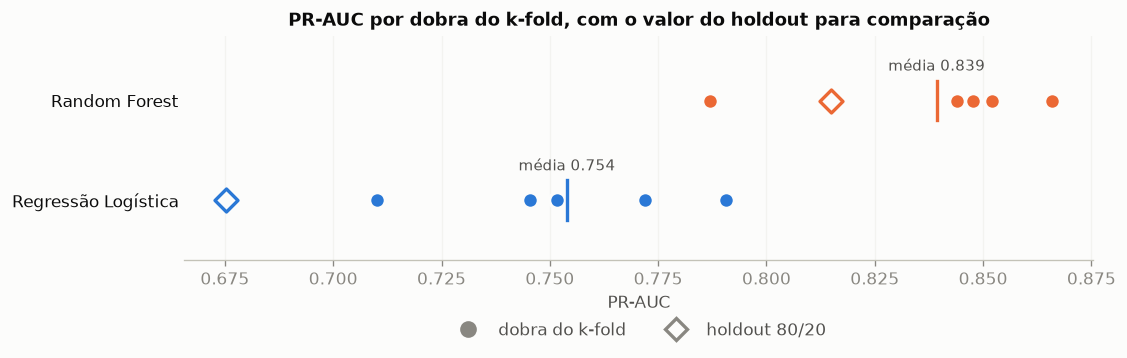

In [29]:
from matplotlib.lines import Line2D

fig, ax = plt.subplots(figsize=(9.5, 3.4))

for i, (nome, cor) in enumerate(CORES.items()):
    dobras = scores_kfold[nome]["test_average_precision"]
    media = dobras.mean()

    # As 5 dobras
    ax.scatter(dobras, np.full(dobras.size, i), s=90, color=cor, zorder=3,
               edgecolor=SUPERFICIE, linewidth=2)
    # Média
    ax.plot([media, media], [i - 0.20, i + 0.20], color=cor, lw=2, zorder=4)
    ax.text(media, i + 0.30, f"média {media:.3f}", color=TINTA_2,
            fontsize=9, ha="center")
    # Valor do holdout
    ax.scatter([tabela_holdout.loc[nome, "PR-AUC"]], [i], s=95, marker="D",
               facecolor=SUPERFICIE, edgecolor=cor, linewidth=2, zorder=5)

ax.set_yticks(range(len(CORES)), list(CORES), color=TINTA)
ax.set_ylim(-0.6, len(CORES) - 0.35)
ax.set_xlabel("PR-AUC")
ax.set_title("PR-AUC por dobra do k-fold, com o valor do holdout para comparação")
ax.grid(axis="y", visible=False)
ax.tick_params(axis="y", length=0)
limpar_bordas(ax, ("top", "right", "left"))

ax.legend(handles=[
    Line2D([], [], marker="o", ls="", ms=9, color=MUDO, label="dobra do k-fold"),
    Line2D([], [], marker="D", ls="", ms=9, markerfacecolor=SUPERFICIE,
           markeredgecolor=MUDO, markeredgewidth=2, color=MUDO, label="holdout 80/20"),
], loc="lower center", ncol=2, labelcolor=TINTA_2, bbox_to_anchor=(0.5, -0.42))

fig.tight_layout()
plt.show()

### 7.3 O custo prático de cada modelo

PR-AUC é um resumo abstrato. Na operação, a escolha se traduz em dois números concretos: quantas
fraudes escaparam e quantos clientes legítimos foram bloqueados por engano.

As duas escalas são muito diferentes (dezenas contra milhares), por isso cada uma tem seu próprio
gráfico — colocá-las num eixo comum esconderia a menor, e num eixo duplo inventaria uma comparação
que não existe.

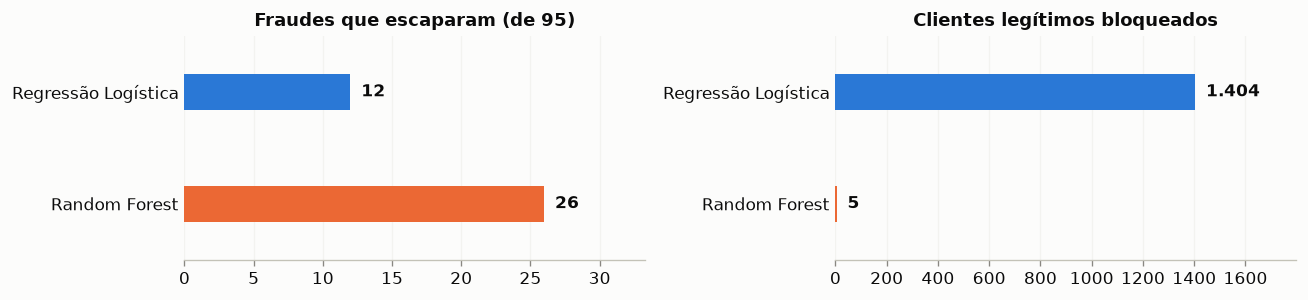

In [30]:
nomes = list(CORES)
cores = [CORES[n] for n in nomes]
matrizes = {n: confusion_matrix(y_test, previsoes[n][0]) for n in nomes}

perdidas = [matrizes[n][1, 0] for n in nomes]     # fraudes que passaram
falsos = [matrizes[n][0, 1] for n in nomes]       # legítimas bloqueadas
total_fraudes = int(y_test.sum())

fig, eixos = plt.subplots(1, 2, figsize=(11, 2.6))

for ax, valores, titulo in zip(
    eixos,
    (perdidas, falsos),
    (f"Fraudes que escaparam (de {total_fraudes})", "Clientes legítimos bloqueados"),
):
    ax.barh(nomes, valores, color=cores, height=0.32)
    for y, v in enumerate(valores):
        ax.text(v + max(valores) * 0.03, y, f"{v:,}".replace(",", "."),
                va="center", color=TINTA, fontsize=10, fontweight="bold")
    ax.set(title=titulo, xlim=(0, max(valores) * 1.28))
    ax.set_ylim(len(nomes) - 0.5, -0.5)
    ax.tick_params(labelcolor=TINTA)
    ax.tick_params(axis="y", length=0)
    ax.grid(axis="y", visible=False)
    limpar_bordas(ax, ("top", "right", "left"))

fig.tight_layout()
plt.show()